<a href="https://colab.research.google.com/github/re-side/ml_basic/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%9B%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D0%B8_%D0%BB%D0%BE%D0%B3%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Практическая работа №5. Линейная и логистическая регрессия**



## **Линейная регрессия**



### **Задание №1. Прогнозирование продаж автомобилей**

- **Шаг 1**: Загрузите набор данных о продажах автомобилей, содержащий информацию о цене, возрасте, пробеге и других характеристиках.
  - **Совет №1**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте `pandas` для обнаружения пропусков (`df.isnull().sum()`) и выбросов (например, с помощью метода межквартильного размаха - `df.boxplot()`).
  - **Совет №2**: Для пропущенных значений используйте стратегию заполнения средними значениями или медианой, чтобы минимизировать влияние на распределение данных (`df.fillna()`).




- Ссылка на набор данных: https://www.kaggle.com/datasets/gagandeep16/car-sales

Пропуски до:
 four_year_resale_value    36
Price_in_thousands         2
Engine_size                1
Horsepower                 1
Wheelbase                  1
Width                      1
Length                     1
Curb_weight                2
Fuel_capacity              1
Fuel_efficiency            3
Power_perf_factor          2
dtype: int64


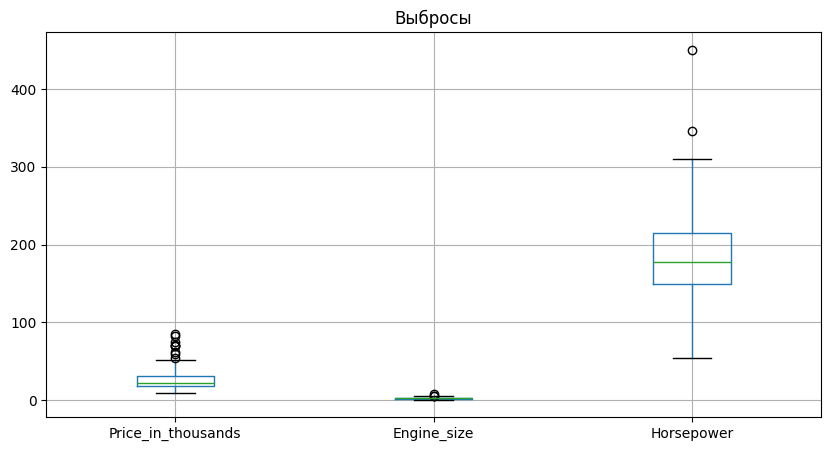


Пропуски после:
 Series([], dtype: int64)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://raw.githubusercontent.com/yashmukaty/Analytics-Case-study/master/Car_sales.csv'
df = pd.read_csv(url)

print("Пропуски до:\n", df.isnull().sum()[df.isnull().sum() > 0])

plt.figure(figsize=(10, 5))
df[['Price_in_thousands', 'Engine_size', 'Horsepower']].boxplot()
plt.title('Выбросы')
plt.show()

num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print("\nПропуски после:\n", df.isnull().sum()[df.isnull().sum() > 0])

- **Шаг 2**: Проведите предварительный анализ данных:
  - Постройте гистограммы для каждого числового признака, чтобы понять их распределение.
  - Постройте диаграммы рассеяния для выявления зависимостей между признаками и целевой переменной (ценой).
  - **Совет**: Используйте корреляционную матрицу для выявления сильных линейных зависимостей между признаками.

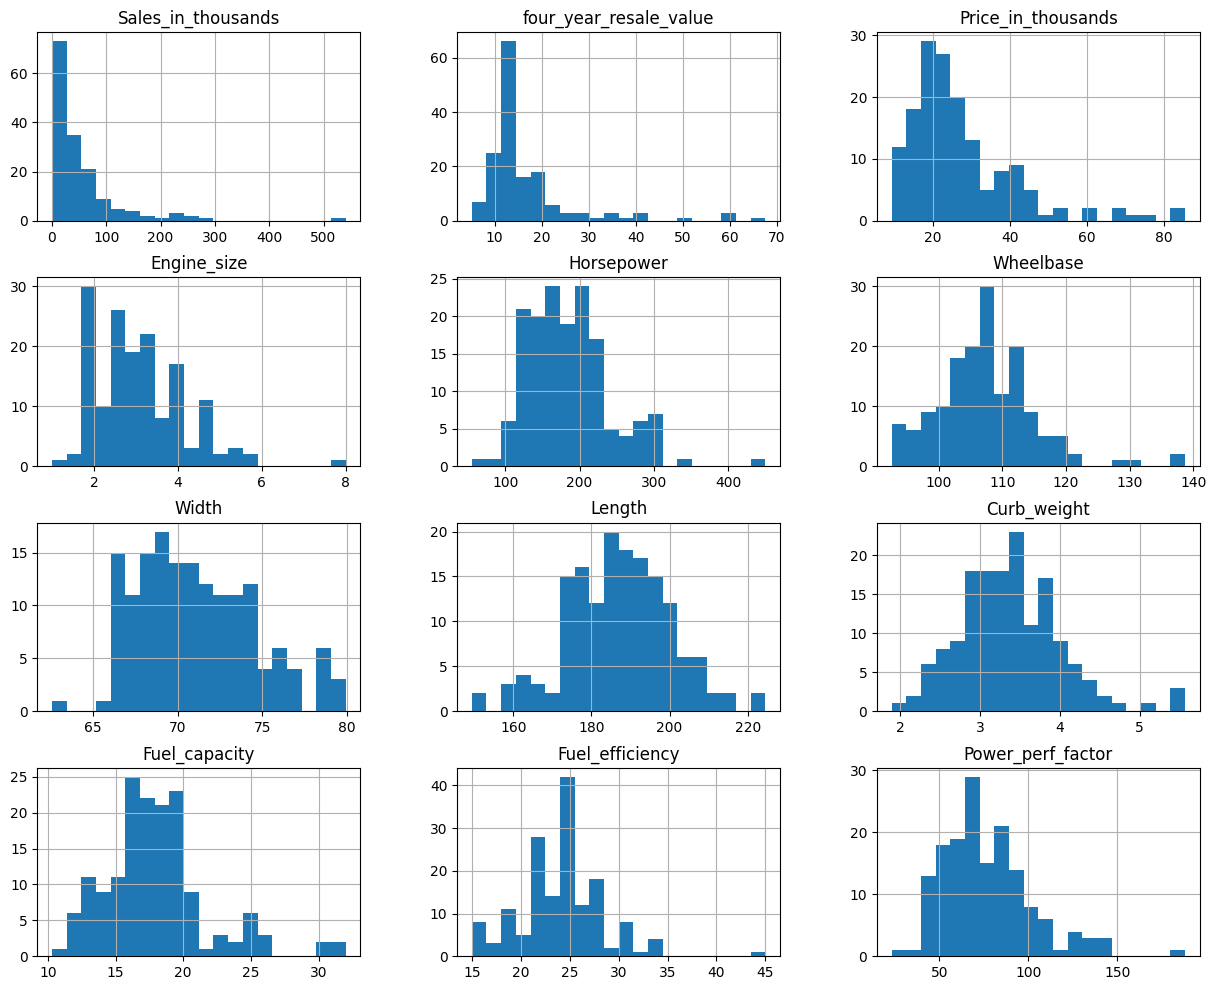

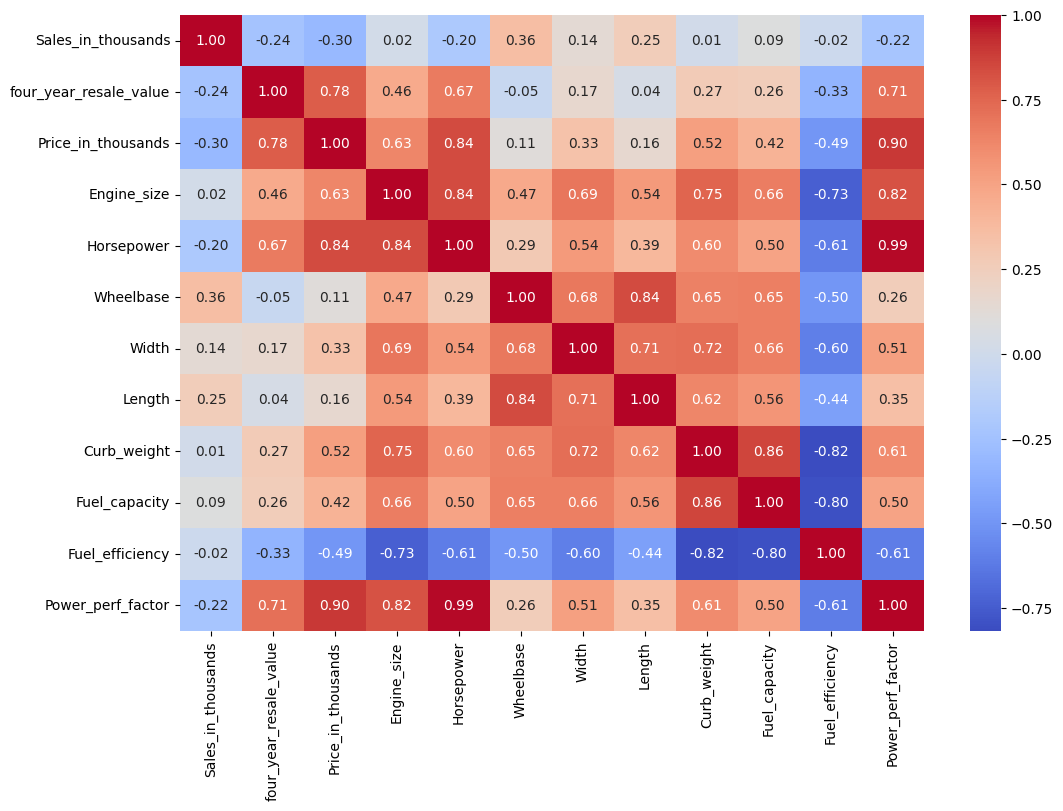

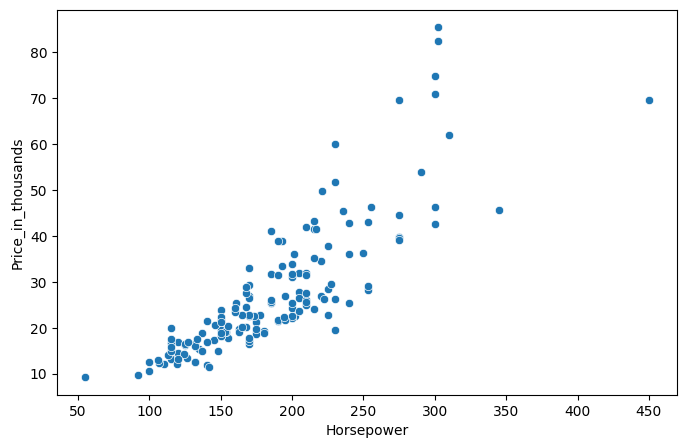

In [ ]:
df.hist(figsize=(15, 12), bins=20)
plt.show()

plt.figure(figsize=(12, 8))
corr_matrix = df.select_dtypes(include='number').corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Horsepower', y='Price_in_thousands')
plt.show()

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки (например, 70% на обучение и 30% на тестирование) с помощью `train_test_split` из `sklearn.model_selection`.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.select_dtypes(include='number').drop('Price_in_thousands', axis=1)
y = df['Price_in_thousands']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (109, 11), y_train: (109,)
X_test: (48, 11), y_test: (48,)


- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **ElasticNet** (комбинация L1 и L2) с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV`.
  - **Совет**: Используйте `np.logspace(-4, 4, 50)` для генерации сетки значений `alpha`.



In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

alphas = np.logspace(-4, 4, 50)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

ridge = GridSearchCV(Ridge(), param_grid={'alpha': alphas}, cv=5)
ridge.fit(X_train_scaled, y_train)

lasso = RandomizedSearchCV(Lasso(max_iter=10000), param_distributions={'alpha': alphas}, n_iter=20, cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)

elastic = GridSearchCV(ElasticNet(max_iter=10000), param_grid={'alpha': alphas, 'l1_ratio':[0.1, 0.5, 0.9]}, cv=5)
elastic.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=ElasticNet(max_iter=10000),
             param_grid={'alpha': array([1.00000000e-04, 1.45634848e-04, 2.12095089e-04, 3.08884360e-04,
       4.49843267e-04, 6.55128557e-04, 9.54095476e-04, 1.38949549e-03,
       2.02358965e-03, 2.94705170e-03, 4.29193426e-03, 6.25055193e-03,
       9.10298178e-03, 1.32571137e-02, 1.93069773e-02, 2.81176870e-02,
       4.09491506e-02, 5.96362332e-0...
       3.72759372e+00, 5.42867544e+00, 7.90604321e+00, 1.15139540e+01,
       1.67683294e+01, 2.44205309e+01, 3.55648031e+01, 5.17947468e+01,
       7.54312006e+01, 1.09854114e+02, 1.59985872e+02, 2.32995181e+02,
       3.39322177e+02, 4.94171336e+02, 7.19685673e+02, 1.04811313e+03,
       1.52641797e+03, 2.22299648e+03, 3.23745754e+03, 4.71486636e+03,
       6.86648845e+03, 1.00000000e+04]),
                         'l1_ratio': [0.1, 0.5, 0.9]})

- **Шаг 5**: Оцените качество всех моделей с использованием метрик MSE, RMSE, MAE и R².
  - Выведите значения метрик для каждой модели и интерпретируйте их.


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def eval_model(model, name, X_t, y_t):
    preds = model.predict(X_t)
    mse = mean_squared_error(y_t, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_t, preds)
    r2 = r2_score(y_t, preds)

    print(f"{name} -> MSE: {mse:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.3f}")
    return {'Model': name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results =[]
results.append(eval_model(lr, "Linear", X_test_scaled, y_test))
results.append(eval_model(ridge.best_estimator_, "Ridge", X_test_scaled, y_test))
results.append(eval_model(lasso.best_estimator_, "Lasso", X_test_scaled, y_test))
results.append(eval_model(elastic.best_estimator_, "ElasticNet", X_test_scaled, y_test))

Linear -> MSE: 7.05, RMSE: 2.65, MAE: 1.95, R2: 0.975
Ridge -> MSE: 11.54, RMSE: 3.40, MAE: 2.47, R2: 0.960
Lasso -> MSE: 10.41, RMSE: 3.23, MAE: 2.27, R2: 0.964
ElasticNet -> MSE: 13.65, RMSE: 3.70, MAE: 2.67, R2: 0.952


- **Шаг 6**: Визуализируйте результаты:
  - Постройте график зависимости предсказанных цен от фактических для каждой модели.



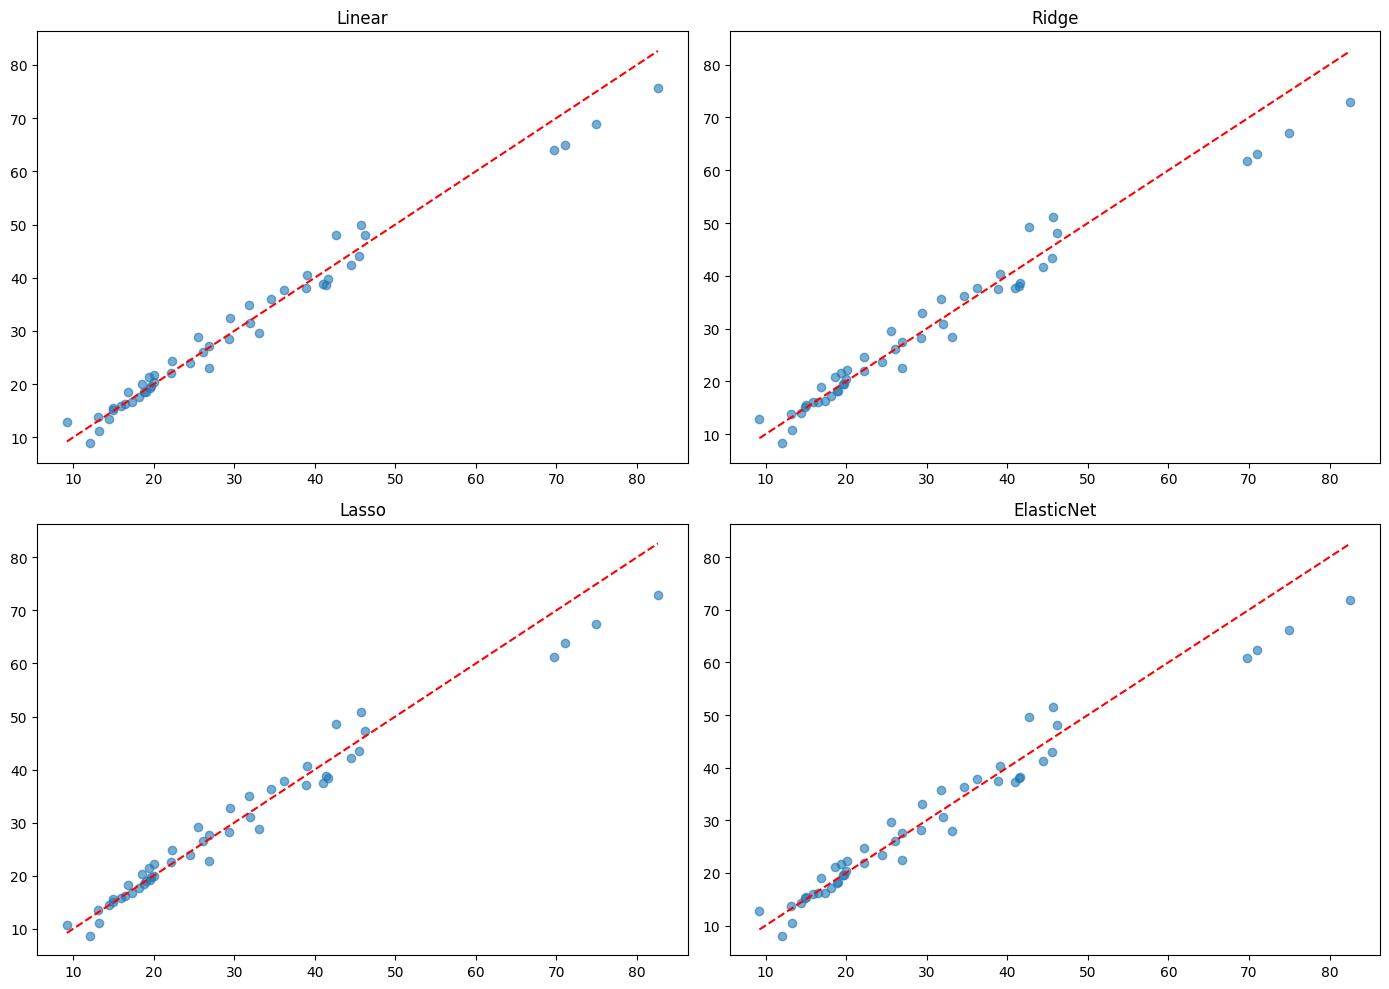

In [ ]:
preds_lr = lr.predict(X_test_scaled)
preds_ridge = ridge.predict(X_test_scaled)
preds_lasso = lasso.predict(X_test_scaled)
preds_elastic = elastic.predict(X_test_scaled)

all_preds = [preds_lr, preds_ridge, preds_lasso, preds_elastic]
titles =['Linear', 'Ridge', 'Lasso', 'ElasticNet']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i in range(4):
    axes[i].scatter(y_test, all_preds[i], alpha=0.6)
    axes[i].plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], color='red', linestyle='--')
    axes[i].set_title(titles[i])

plt.tight_layout()
plt.show()



- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.


In [ ]:
results_df = pd.DataFrame(results)
display(results_df)

best = results_df.loc[results_df['R2'].idxmax()]

print("\nЛучшая модель:\n", best)
print("\nГиперпараметры:")
print("Ridge alpha:", ridge.best_params_['alpha'])
print("Lasso alpha:", lasso.best_params_['alpha'])
print("ElasticNet params:", elastic.best_params_)

,Model,MSE,RMSE,MAE,R2
0,Linear,7.047362,2.654687,1.954663,0.975417
1,Ridge,11.539473,3.396980,2.468280,0.959747
2,Lasso,10.408901,3.226283,2.265499,0.963690
3,ElasticNet,13.654603,3.695214,2.666736,0.952368



Лучшая модель:
 Model      Linear
MSE      7.047362
RMSE     2.654687
MAE      1.954663
R2       0.975417
Name: 0, dtype: object

Гиперпараметры:
Ridge alpha: 0.2682695795279725
Lasso alpha: 0.05963623316594643
ElasticNet params: {'alpha': np.float64(0.004291934260128779), 'l1_ratio': 0.1}


---



### **Задание №2. Влияние погодных условий на урожайность**




- **Шаг 1**: Загрузите набор данных о погодных условиях и урожайности сельскохозяйственных культур.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.

- Ссылка на набор данных: https://www.kaggle.com/datasets/waqi786/climate-change-impact-on-agriculture


In [11]:
import pandas as pd
import kagglehub
import os

path = kagglehub.dataset_download("waqi786/climate-change-impact-on-agriculture")

csv_file =[f for f in os.listdir(path) if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

df = pd.read_csv(full_path)

num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print("Осталось пропусков:", df.isnull().sum().sum())

100%|██████████| 327k/327k [00:00<00:00, 53.1MB/s]

Extracting files...
Осталось пропусков: 0





- **Шаг 2**: Выполните анализ данных:
  - Постройте корреляционную матрицу для выявления зависимостей между признаками.
  - Постройте диаграммы рассеяния для ключевых признаков.
  - **Совет**: Удалите или преобразуйте признаки с низкой корреляцией с целевой переменной, чтобы улучшить модель.



In [ ]:
# Ваш код

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [ ]:
# Ваш код



- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации для оценки влияния температуры и уровня осадков на урожайность:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **ElasticNet** с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

# Ваш код

- **Шаг 5**: Проведите оценку точности всех моделей.
  - Выведите значения метрик MSE, RMSE, MAE и R² для каждой модели и интерпретируйте их.

In [ ]:
# Ваш код



- **Шаг 6**: Визуализируйте данные и результаты моделей:
  - Постройте графики зависимости предсказанных значений от фактических для каждой модели.

In [ ]:
# Ваш код

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.

In [ ]:
# Ваш код

- **Шаг 8: Проанализируйте влияние признаков на урожайность**

  - На основе лучшей модели проведите анализ важности признаков:

    - Извлеките коэффициенты (`coef_`) лучшей модели и сопоставьте их с названиями признаков.
    - Визуализируйте важность признаков с помощью горизонтальной столбчатой диаграммы.
    - Проинтерпретируйте результаты: определите, какие погодные факторы (температура, осадки, CO₂ и др.) оказывают наибольшее положительное и отрицательное влияние на урожайность.
    - **Совет**: Для модели Lasso обратите внимание на признаки с нулевыми коэффициентами — они были исключены как незначимые.
    - **Совет**: Если данные были стандартизированы (`StandardScaler`), коэффициенты можно напрямую сравнивать по абсолютной величине для оценки относительной важности.



In [ ]:
# Ваш код

#### **Интерпретация результатов (пример формулировки для отчёта):**


**[ТРЕБУЕТСЯ ЗАПОЛНИТЬ!]**


> На основе анализа коэффициентов лучшей модели установлено, что:
> - **Положительное влияние** на урожайность оказывают: [перечислить признаки с положительными коэффициентами].
> - **Отрицательное влияние** на урожайность оказывают: [перечислить признаки с отрицательными коэффициентами].
> - Наиболее значимым фактором является [название признака] с коэффициентом [значение], что означает: при увеличении данного показателя на 1 единицу (при прочих равных) урожайность изменяется на [значение коэффициента] единиц.

---



## **Логистическая регрессия**



### **Задание №3. Классификация клиентов банка**

- **Шаг 1**: Загрузите набор данных о клиентах банка, включающий данные о возрасте, доходе, кредитной истории и других характеристиках.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.



- Ссылка на набор данных: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing/data

In [ ]:
# Ваш код

- **Шаг 2**: Проведите анализ данных и предобработку:
  - Закодируйте категориальные переменные с помощью `OneHotEncoder` или `pd.get_dummies`.
  - Нормализуйте числовые признаки с помощью `StandardScaler` для улучшения обучения модели.
  - **Совет**: Убедитесь, что все признаки имеют одинаковый масштаб, чтобы избежать доминирования одного признака над другими.

In [ ]:
# Ваш код

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [ ]:
# Ваш код

- **Шаг 4**: Постройте и обучите модели логистической регрессии с различными типами регуляризации для предсказания вероятности открытия депозитного счета клиентом:
  - Обучите модель `LogisticRegression` с **L2-регуляризацией** (`penalty='l2'`) и подбором гиперпараметра `C` с помощью `GridSearchCV`.
  - Обучите модель `LogisticRegression` с **L1-регуляризацией** (`penalty='l1'`, `solver='saga'`) и подбором гиперпараметра `C` с помощью `RandomizedSearchCV`.
  - Обучите модель `LogisticRegression` с **ElasticNet-регуляризацией** (`penalty='elasticnet'`, `solver='saga'`) и подбором гиперпараметров `C` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .
  - **Совет**: Для L1 и ElasticNet используйте `solver='saga'`, так как он поддерживает оба типа регуляризации.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np


# Ваш код


- **Шаг 5**: Оцените качество всех моделей с использованием метрик точности (Accuracy), полноты (Recall), точности (Precision) и F1-меры.
  - Выведите значения метрик для каждой модели и интерпретируйте их. Обратите внимание на баланс между точностью и полнотой.
  - Постройте матрицу ошибок для каждой модели с помощью `confusion_matrix` и визуализируйте их с помощью `seaborn.heatmap`.

In [ ]:
# Ваш код

- **Шаг 6**: Визуализируйте ROC-кривые для всех моделей и вычислите AUC для оценки.
  - Используйте `roc_curve` и `auc` из `sklearn.metrics` для построения и расчёта.
  - Постройте все ROC-кривые на одном графике для наглядного сравнения.



In [ ]:
# Ваш код

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (Accuracy, Precision, Recall, F1, AUC)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, оптимальные гиперпараметры и матрицу ошибок.

In [ ]:
# Ваш код